# Forcing field for WIND- experiment

This notebook creates the zonal wind forcing file used in the WIND- perturbation experiment.

First it creates a region mask in the Amundsen Sea.

Then, using this mask, we subtract 50% of the rolling monthly mean u wind velocities to the original JRA55 u winds. By using the rolling monthly mean, we ensure that we're not amplifying the storm activity, and also minimising change to the seasonal cycle. For example, the easterlies in the control are strong in winter and weak in summer, so if we were to add/subtract a constant fraction of the annual wind speed (rather than monthly wind as we do here), we would inadvertently be overly strengthening the summer winds compared to the winter winds.

This notebook is a modified version of https://github.com/adele-morrison/easterlies-collaborative-project/blob/master/notebooks/forcing_perturbation/JRA_wind_perturbation_setup.ipynb

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import shutil as shutil
import scipy.ndimage
import matplotlib.path as mpath
import sys
sys.path.append(
    "/g/data/e14/cs6673/Ross_salinity/Python_scripts_published/") 
from Info_definitions import (path_control, exptdict)
import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)
from dask.distributed import Client

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36731,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35717,Total threads: 4
Dashboard: /proxy/40353/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:43215,


## Open ocean bathymetry:

In [3]:
# open bathymetry and shift to JRA forcing coordinates:
ht = xr.open_dataset(
    path_control + 'output1000/ocean/ocean_grid.nc').ht
# find index where xt_ocean>=0 to roll coords:
xt_ocean = ht.xt_ocean
shift_index = np.where(xt_ocean>=0)[0][0]
ht = ht.roll(xt_ocean=-shift_index,roll_coords=True)
# make xt_ocean go from 0 to 360:
shift_xt_ocean = ht.xt_ocean
new_xt_ocean = np.where(shift_xt_ocean<0,shift_xt_ocean+360,shift_xt_ocean)
ht.coords['xt_ocean'] = new_xt_ocean

land_mask = np.squeeze(ht.values)*0
land_mask[np.isnan(land_mask)] = 1
land_mask = np.where(land_mask==1,land_mask,np.nan)
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)

## Open the JRA9091 zonal wind file:

In [4]:
u_file = '/g/data/ik11/inputs/JRA-55/RYF/v1-3/RYF.u_10.1990_1991.nc'
ds = xr.open_dataset(u_file,decode_times=False)
u = ds.uas_10m
u = u.load()
u_mean = u.mean('time')

## Create mask to modify winds in the Amundsen Sea
This will be equal to 1 where we want to apply the perturbation and 0 everywhere else, with smoothing between the 2 regions

In [5]:
def mask_from_polygon(lon, lat, xt_ocean, yt_ocean):
    polygon = [(lon[0], lat[0])]
    for l in range(1, len(lon)):
        polygon += [(lon[l], lat[l])]
    poly_path = mpath.Path(polygon)

    x, y = xr.broadcast(xt_ocean, yt_ocean)
    coors = np.hstack((x.values.reshape(-1, 1), y.values.reshape(-1, 1)))

    mask = poly_path.contains_points(coors)
    mask = mask.reshape(xt_ocean.size, yt_ocean.size).transpose()
    mask = xr.DataArray(
        mask, dims = ['latitude', 'longitude'],
        coords={'longitude': xt_ocean, 'latitude': yt_ocean})
    return mask

In [6]:
e = exptdict['wind_50_down_zonal']
buffer = -1.2
mask_wind_lon = e['mask_wind'][0]
mask_wind_lat = e['mask_wind'][1]

mask_wind = mask_from_polygon(
    mask_wind_lon, mask_wind_lat,
    u_mean.longitude, u_mean.latitude)
mask_wind = mask_wind.where(mask_wind == True, 0.)
mask_wind = mask_wind.where(mask_wind == 0., 1.)

# smooth mask
wind_mask = scipy.ndimage.gaussian_filter(mask_wind.values,sigma=1)

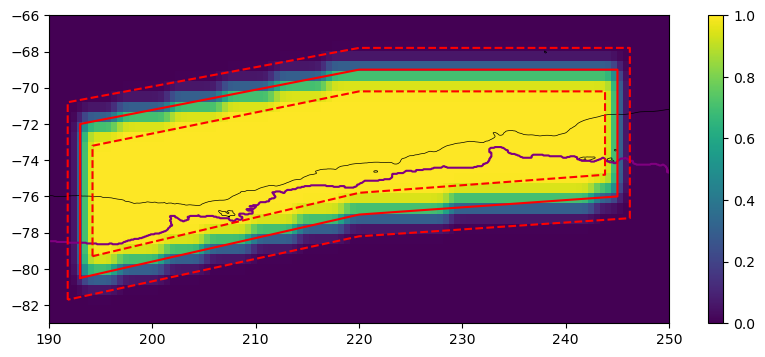

In [7]:
plt.figure(figsize=(10, 4))
plt.pcolormesh(mask_wind.longitude,mask_wind.latitude,wind_mask)
plt.colorbar()
cs = plt.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000],linewidths=0.5,colors='k',
            label='1000 m isobath')
cs = plt.contour(ht.xt_ocean,ht.yt_ocean,np.where(land_mask == 1, 1, 0),levels=[0.5],
            colors='purple', label='coastline')
plt.ylim(-83, -66)
plt.xlim(190, 250)

plt.plot(mask_wind_lon, mask_wind_lat, color='r')
for buffer_pm in [-1.2, 1.2]:
    plt.plot([e['mask_wind'][0][0]-buffer_pm, e['mask_wind'][0][1]-buffer_pm,
              e['mask_wind'][0][2], e['mask_wind'][0][3]+buffer_pm,
              e['mask_wind'][0][4]+buffer_pm, e['mask_wind'][0][5],
              e['mask_wind'][0][6]-buffer_pm],
             [e['mask_wind'][1][0]-buffer_pm, e['mask_wind'][1][1]+buffer_pm,
              e['mask_wind'][1][2]+buffer_pm, e['mask_wind'][1][3]+buffer_pm,
              e['mask_wind'][1][4]-buffer_pm, e['mask_wind'][1][5]-buffer_pm,
              e['mask_wind'][1][6]-buffer_pm],
             color='r', linestyle='--')

## Now we want to compute the rolling monthly mean, and we will substract 50% of this from the original JRA winds

In [8]:
# calculate masked rolling monthly mean to add to existing wind:

# first pad start and end of year, so rolling mean wraps around Dec/Jan division:
u_pad = u.pad(time=15*8, mode='wrap') # pad with 15 days of data to allow for monthly averages

# compute rolling mean using a 30 day window:
u_monthly_mean = u_pad.rolling(time=8*30,center=True).mean().dropna('time')

# this somehow ends up with 1 timestep too many, drop last time index to fix:
u_monthly_mean = u_monthly_mean[:-1,:,:]

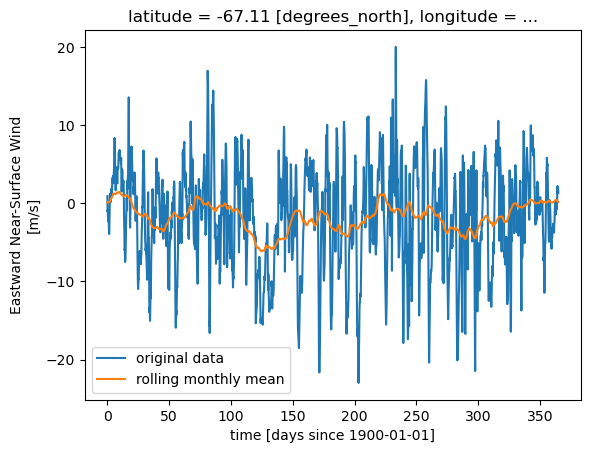

In [9]:
# check it looks sensible for sample location:
u[:,40,0].plot(label='original data')
u_monthly_mean[:,40,0].plot(label='rolling monthly mean')
plt.legend()
plt.show()

In [10]:
change_perc = 0.50
u_addition = change_perc*wind_mask*u_monthly_mean
u_mod = u - u_addition

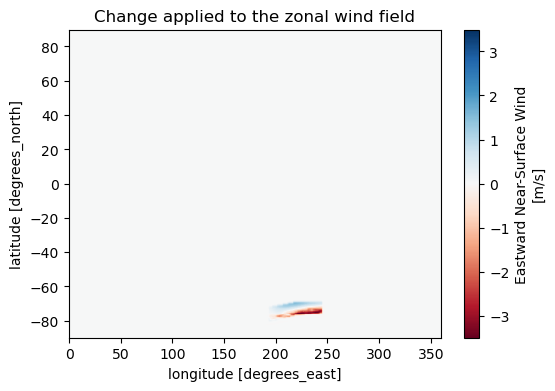

In [14]:
plt.figure(figsize=(6, 4))

u_addition.mean('time').plot(cmap='RdBu')
plt.title('Change applied to the zonal wind field')

plt.show()

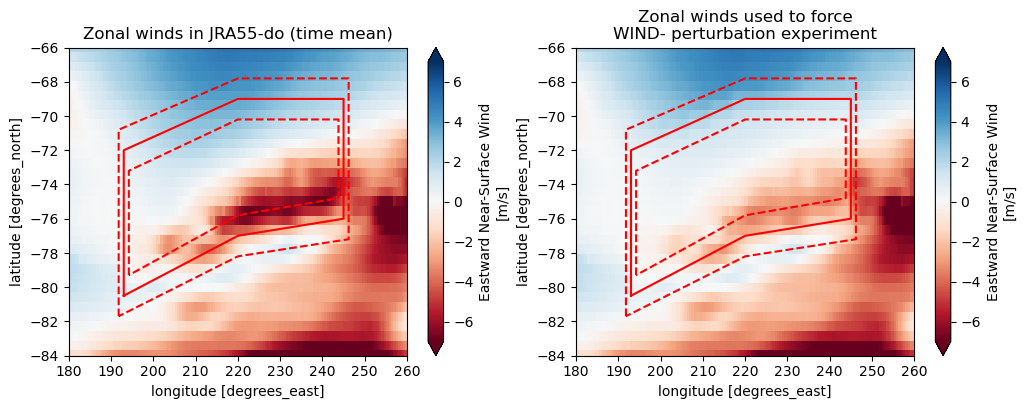

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
u.mean('time').plot(vmin=-7, vmax=7, cmap='RdBu')
plt.ylim(-84, -66)
plt.xlim(180, 260)
plt.plot(mask_wind_lon, mask_wind_lat, color='r')
for buffer_pm in [-1.2, 1.2]:
    plt.plot([e['mask_wind'][0][0]-buffer_pm, e['mask_wind'][0][1]-buffer_pm,
              e['mask_wind'][0][2], e['mask_wind'][0][3]+buffer_pm,
              e['mask_wind'][0][4]+buffer_pm, e['mask_wind'][0][5],
              e['mask_wind'][0][6]-buffer_pm],
             [e['mask_wind'][1][0]-buffer_pm, e['mask_wind'][1][1]+buffer_pm,
              e['mask_wind'][1][2]+buffer_pm, e['mask_wind'][1][3]+buffer_pm,
              e['mask_wind'][1][4]-buffer_pm, e['mask_wind'][1][5]-buffer_pm,
              e['mask_wind'][1][6]-buffer_pm],
             color='r', linestyle='--')
plt.title('Zonal winds in JRA55-do (time mean)')

plt.subplot(1, 2, 2)
u_mod_NDJF = xr.concat((u_mod[:480], u_mod[-480:]), dim='time').mean(
    'time')
u_mod.mean('time').plot(vmin=-7, vmax=7, cmap='RdBu')
plt.ylim(-84, -66)
plt.xlim(180, 260)
plt.plot(mask_wind_lon, mask_wind_lat, color='r')
for buffer_pm in [-1.2, 1.2]:
    plt.plot([e['mask_wind'][0][0]-buffer_pm, e['mask_wind'][0][1]-buffer_pm,
              e['mask_wind'][0][2], e['mask_wind'][0][3]+buffer_pm,
              e['mask_wind'][0][4]+buffer_pm, e['mask_wind'][0][5],
              e['mask_wind'][0][6]-buffer_pm],
             [e['mask_wind'][1][0]-buffer_pm, e['mask_wind'][1][1]+buffer_pm,
              e['mask_wind'][1][2]+buffer_pm, e['mask_wind'][1][3]+buffer_pm,
              e['mask_wind'][1][4]-buffer_pm, e['mask_wind'][1][5]-buffer_pm,
              e['mask_wind'][1][6]-buffer_pm],
             color='r', linestyle='--')
plt.title('Zonal winds used to force\nWIND- perturbation experiment')

plt.show()

## Save new wind speed to files

In [21]:
# to ensure metadata etc is correct, copy old files and overwrite data:
path_output = '/g/data/e14/cs6673/Ross_salinity/forcing_perturbed/'

###### Save perturbed wind fields
u_modified = u - u_addition
# new file names:
new_u_file = path_output + 'RYF_winds_decreased_' + str(int(change_perc*100)) + '.u_10.1990_1991.nc'
# copy old files into new file paths:
shutil.copyfile(u_file, new_u_file)
# then overwrite the variables in the new files with the new data:
ncFile = nc.Dataset(new_u_file, 'r+')
ncFile.variables['uas_10m'][...] = u_modified.values
ncFile.close()